# Trader Performance vs Market Sentiment Analysis

This analysis explores how market sentiment (Fear, Greed, Neutral) affects trader behavior and performance.

The goal is to:
- Understand how profitability changes with sentiment
- Analyze trading behavior (size, frequency, etc.)
- Identify patterns that can help form better trading strategies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data1 = pd.read_csv(r"C:\Users\Admin\Spyder FirstDirectory\fear_greed_index.csv")
data2 = pd.read_csv(r"C:\Users\Admin\Spyder FirstDirectory\historical_data.csv")

data1.head()
data2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Data Understanding

- Dataset 1 contains daily market sentiment (Fear/Greed index)
- Dataset 2 contains individual trade-level data

Checking basic details like date ranges, columns, and sentiment categories

In [3]:
print(data1["date"].min())
print(data1["date"].max())

print(data2.columns)

print(data1["classification"].unique())

2018-02-01
2025-05-02
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']


In [8]:
## Cleaning Sentiment Labels

##Combining "Extreme Fear" with "Fear" and "Extreme Greed" with "Greed" to simplify analysis
data1upd = data1.copy()

data1upd["classification"] = data1upd["classification"].replace("Extreme Fear", "Fear")
data1upd["classification"] = data1upd["classification"].replace("Extreme Greed", "Greed")

print(data1upd["classification"].unique())

['Fear' 'Neutral' 'Greed']


In [9]:
## Converting Timestamps

##Extracting date from trade timestamps so both datasets can be aligned
data2['Timestamp IST'] = pd.to_datetime(data2['Timestamp IST'], dayfirst=True)
data2['date'] = data2['Timestamp IST'].dt.date
data2["date"] = pd.to_datetime(data2["date"])

data1upd["date"] = pd.to_datetime(data1upd["date"])

In [10]:
merged_df = pd.merge(data2, data1upd, on="date", how="left")

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

## Data Cleaning

- Dropping missing values
- Renaming columns for clarity

In [11]:
merged_df = merged_df.dropna()

merged_df = merged_df.rename(columns={
    "classification": "sentiment",
    "Closed PnL": "Pnl"
})

## Creating Performance Metrics

A trade is considered a "win" if PnL > 0

In [12]:
merged_df['Win'] = np.where(merged_df['Pnl'] > 0, 1, 0)

In [14]:
## Performance by Sentiment (Before Cleaning)

##Looking at average PnL, win rate, and trade size across sentiment
sentiment_summary = merged_df.groupby('sentiment').agg({
    'Win': 'mean',
    'Pnl': 'mean',
    'Size USD': 'mean'
}).reset_index()

print(sentiment_summary)

  sentiment       Win        Pnl     Size USD
0      Fear  0.407871  49.212077  7182.011019
1     Greed  0.420311  53.882281  4574.424490
2   Neutral  0.396991  34.307718  4782.732661


## Checking Zero PnL Trades

Many trades have zero PnL, which can distort results

In [15]:
print(((merged_df["Pnl"] == 0).sum()) / len(merged_df))

0.505714475092085


## Removing Zero PnL Trades

Filtering out trades with zero PnL for more accurate analysis

In [17]:
merged_df = merged_df[merged_df["Pnl"] != 0]

## Performance by Sentiment (After Cleaning)

Recomputing metrics after removing zero PnL trades

In [18]:
sentiment_summaryupd = merged_df.groupby('sentiment').agg({
    'Win': 'mean',
    'Pnl': 'mean',
    'Size USD': 'mean'
}).reset_index()

print(sentiment_summaryupd)

  sentiment       Win         Pnl     Size USD
0      Fear  0.844233  101.861682  7375.189043
1     Greed  0.824524  105.700767  4233.988154
2   Neutral  0.823889   71.199993  5556.444833


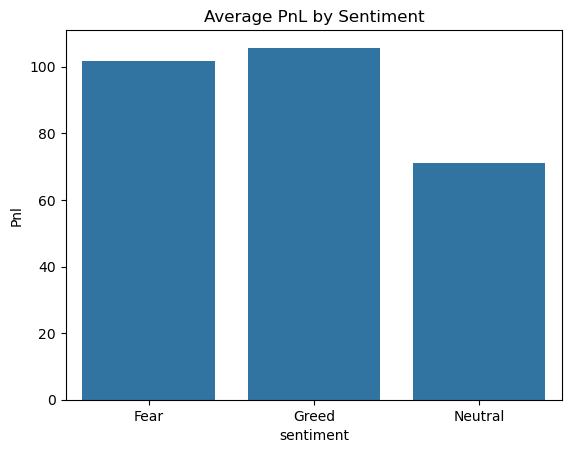

In [21]:
plt.figure()
sns.barplot(data=sentiment_summaryupd, x='sentiment', y='Pnl')
plt.title("Average PnL by Sentiment")
plt.show()

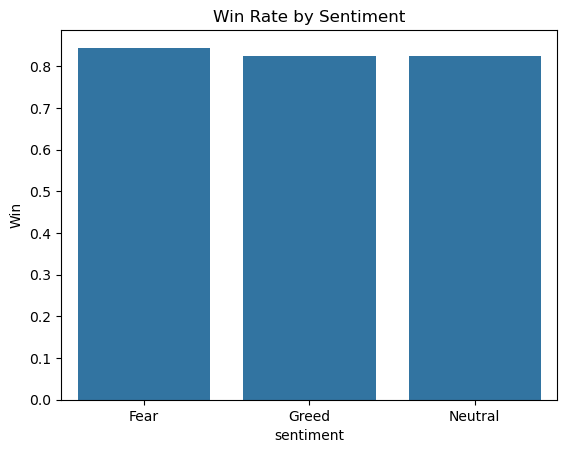

In [22]:
plt.figure()
sns.barplot(data=sentiment_summaryupd, x='sentiment', y='Win')
plt.title("Win Rate by Sentiment")
plt.show()

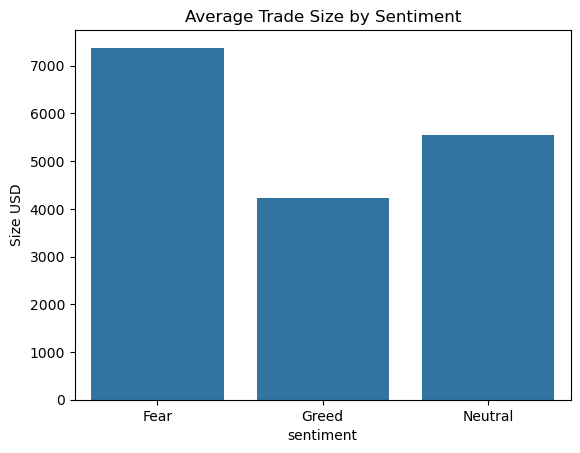

In [23]:
plt.figure()
sns.barplot(data=sentiment_summaryupd, x='sentiment', y='Size USD')
plt.title("Average Trade Size by Sentiment")
plt.show()

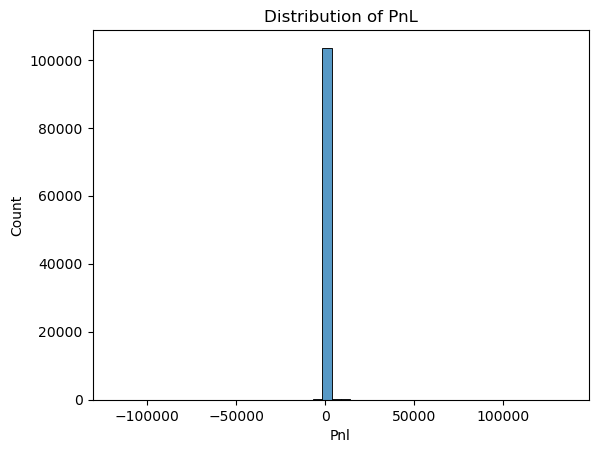

In [24]:
plt.figure()
sns.histplot(merged_df['Pnl'], bins=50)
plt.title("Distribution of PnL")
plt.show()

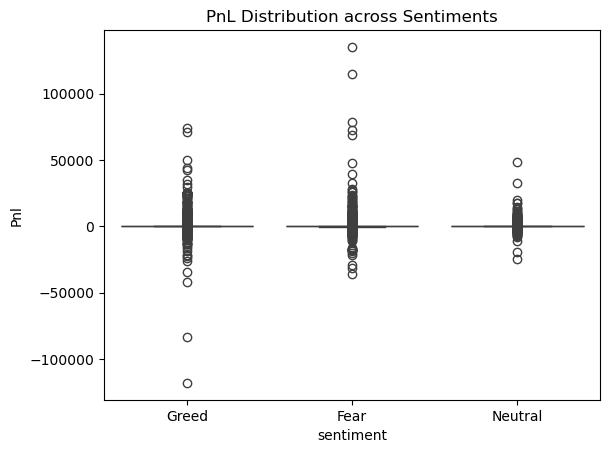

In [25]:
plt.figure()
sns.boxplot(data=merged_df, x='sentiment', y='Pnl')
plt.title("PnL Distribution across Sentiments")
plt.show()

## Segmentation: High vs Low Trade Size

Dividing traders into:
- High size (above median)
- Low size (below median)

In [19]:
med = merged_df["Size USD"].median()

merged_df["Seg1"] = np.where(
    merged_df["Size USD"] > med,
    "High",
    "Low"
)

## Performance by Segment and Sentiment

In [20]:
sentiment_analysis_seg1 = merged_df.groupby(["Seg1", "sentiment"]).agg({
    'Win': 'mean',
    'Pnl': 'mean',
    'Size USD': 'mean'
}).reset_index()

print(sentiment_analysis_seg1)

   Seg1 sentiment       Win         Pnl      Size USD
0  High      Fear  0.848782  175.508791  12868.700739
1  High     Greed  0.844059  220.921027   9186.092100
2  High   Neutral  0.828026  141.211080  11160.317370
3   Low      Fear  0.838332    6.320284    248.530539
4   Low     Greed  0.808648   12.065305    209.587059
5   Low   Neutral  0.819951    4.552870    221.832860


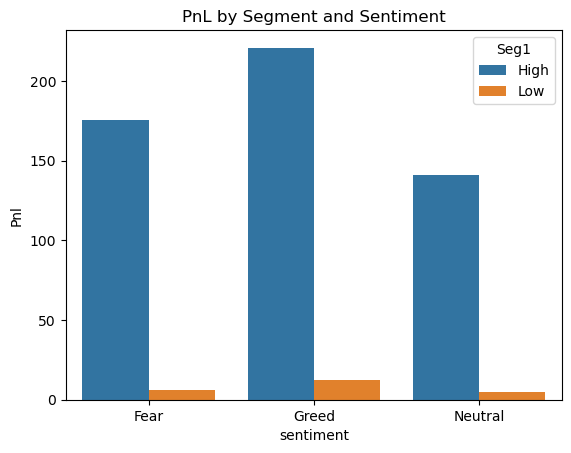

In [26]:
plt.figure()
sns.barplot(data=sentiment_analysis_seg1, x='sentiment', y='Pnl', hue='Seg1')
plt.title("PnL by Segment and Sentiment")
plt.show()

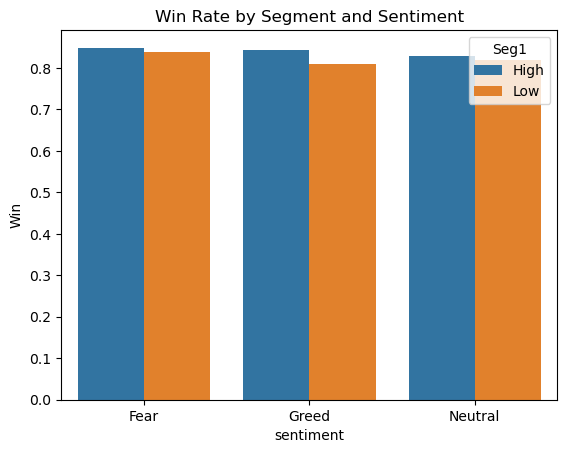

In [27]:
plt.figure()
sns.barplot(data=sentiment_analysis_seg1, x='sentiment', y='Win', hue='Seg1')
plt.title("Win Rate by Segment and Sentiment")
plt.show()

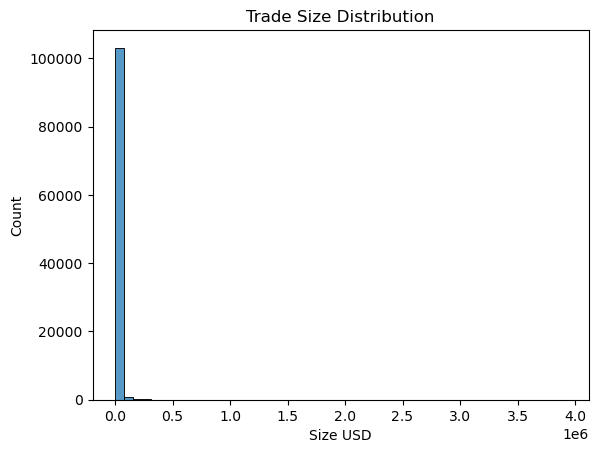

In [28]:
plt.figure()
sns.histplot(merged_df['Size USD'], bins=50)
plt.title("Trade Size Distribution")
plt.show()

## Key Insights

1. Traders tend to achieve higher profits during Greed periods, although win rate is slightly higher during Fear.
2. Trade sizes are largest during Fear, suggesting higher risk-taking behavior.
3. Neutral markets show the lowest profitability, indicating lack of clear opportunities.
4. High-size traders contribute the majority of profits, while low-size traders have minimal returns.

## Strategy Recommendations

1. During Greed periods, traders can consider slightly increasing exposure to capture larger price movements.
2. During Fear periods, reducing trade size may help manage risk, as higher exposure does not necessarily lead to higher returns.